# Road Performance Analysis & Modeling
Analisis performa jalan tambang: EDA + Model Comparison untuk Feature Importance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE, mutual_info_regression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print('Library loaded!')

c:\Profesional\Python\Analisis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Library loaded!


---
## 1. Import & Cleaning Data

In [2]:
FILE_PATH = '../DATA JALAN PER WEEK.xlsx'

df = pd.read_excel(FILE_PATH, usecols='B:N', engine='openpyxl')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
df.head(10)

Rows: 472, Columns: 13


,WEEK,Road Segment,Count Cycle,Avg. Truck Per Hour,Average of DISTANCE_METER,Plan Speed Per Segment,Act. Speed Per Segment,Grade,Crossfall,Lebar Jalan,Min Lebar Jalan,HRSI,Sudut Jalan
0,26,Jalan Alphard S01,1175,29.0,0.209155,23.950000,26.13,0.045000,0.025700,25.680000,21.981,7.714286,0.0
1,26,Jalan Alphard S02,1187,29.0,0.723199,23.950000,25.14,0.058100,0.014667,27.249667,24.735,8.875000,0.0
2,26,Jalan Asfri S04,2,NaN,0.675945,23.950000,19.17,0.022000,0.027975,29.632750,26.025,10.000000,77.8
3,26,Jalan Astin S01,633,18.0,0.352394,23.950000,26.23,0.042980,0.017760,28.663400,24.000,7.000000,0.0
4,26,Jalan Astin2 S02,113,8.0,0.404419,23.859375,24.47,0.057667,0.022033,24.858000,20.500,10.000000,0.0
5,26,Jalan Astin2 S03,114,8.0,1.138172,23.442857,27.78,0.061000,0.017300,25.440000,24.793,10.000000,0.0
6,26,Jalan Astin2 S05,113,8.0,0.290966,25.102564,29.53,0.050750,0.004400,21.545500,20.091,4.000000,90.0
7,26,Jalan Ayla S03,183,6.0,0.465730,29.120408,27.75,0.037500,0.020000,23.489667,21.562,8.000000,0.0
8,26,Jalan Ayla S04,184,6.0,0.878888,27.995000,28.57,0.066075,0.020675,27.608500,24.322,2.333333,107.0
9,26,Jalan Brio S01,111,8.0,0.130993,19.831667,19.10,0.001000,0.023600,44.049000,44.049,2.000000,47.9


In [3]:
# 1. Handle missing values - fill dengan median per road segment, fallback ke median global
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df.groupby('Road Segment')[col].transform(lambda x: x.fillna(x.median()))
    df[col] = df[col].fillna(df[col].median())

# 2. Konversi tipe data
df['WEEK'] = df['WEEK'].astype(str)
df['Road Segment'] = df['Road Segment'].astype('category')

# 3. Feature engineering
df['Speed_Ratio'] = df['Act. Speed Per Segment'] / df['Plan Speed Per Segment']
df['Speed_Deviation'] = df['Act. Speed Per Segment'] - df['Plan Speed Per Segment']
df['Lebar_Valid'] = df['Min Lebar Jalan'] <= df['Lebar Jalan']
df['Grade_Category'] = pd.cut(df['Grade'], bins=[0, 0.03, 0.06, 0.10, 1.0],
                               labels=['Flat', 'Medium', 'Steep', 'Very Steep'])

print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
df.head(10)

Missing values: 0
Rows: 472, Columns: 17


,WEEK,Road Segment,Count Cycle,Avg. Truck Per Hour,Average of DISTANCE_METER,Plan Speed Per Segment,Act. Speed Per Segment,Grade,Crossfall,Lebar Jalan,Min Lebar Jalan,HRSI,Sudut Jalan,Speed_Ratio,Speed_Deviation,Lebar_Valid,Grade_Category
0,26,Jalan Alphard S01,1175,29.0,0.209155,23.950000,26.13,0.045000,0.025700,25.680000,21.981,7.714286,0.0,1.091023,2.180000,True,Medium
1,26,Jalan Alphard S02,1187,29.0,0.723199,23.950000,25.14,0.058100,0.014667,27.249667,24.735,8.875000,0.0,1.049687,1.190000,True,Medium
2,26,Jalan Asfri S04,2,52.0,0.675945,23.950000,19.17,0.022000,0.027975,29.632750,26.025,10.000000,77.8,0.800418,-4.780000,True,Flat
3,26,Jalan Astin S01,633,18.0,0.352394,23.950000,26.23,0.042980,0.017760,28.663400,24.000,7.000000,0.0,1.095198,2.280000,True,Medium
4,26,Jalan Astin2 S02,113,8.0,0.404419,23.859375,24.47,0.057667,0.022033,24.858000,20.500,10.000000,0.0,1.025593,0.610625,True,Medium
5,26,Jalan Astin2 S03,114,8.0,1.138172,23.442857,27.78,0.061000,0.017300,25.440000,24.793,10.000000,0.0,1.185009,4.337143,True,Steep
6,26,Jalan Astin2 S05,113,8.0,0.290966,25.102564,29.53,0.050750,0.004400,21.545500,20.091,4.000000,90.0,1.176374,4.427436,True,Medium
7,26,Jalan Ayla S03,183,6.0,0.465730,29.120408,27.75,0.037500,0.020000,23.489667,21.562,8.000000,0.0,0.952940,-1.370408,True,Medium
8,26,Jalan Ayla S04,184,6.0,0.878888,27.995000,28.57,0.066075,0.020675,27.608500,24.322,2.333333,107.0,1.020539,0.575000,True,Steep
9,26,Jalan Brio S01,111,8.0,0.130993,19.831667,19.10,0.001000,0.023600,44.049000,44.049,2.000000,47.9,0.963106,-0.731667,True,Flat


---
## 2. EDA - Distribusi Variabel Numerik

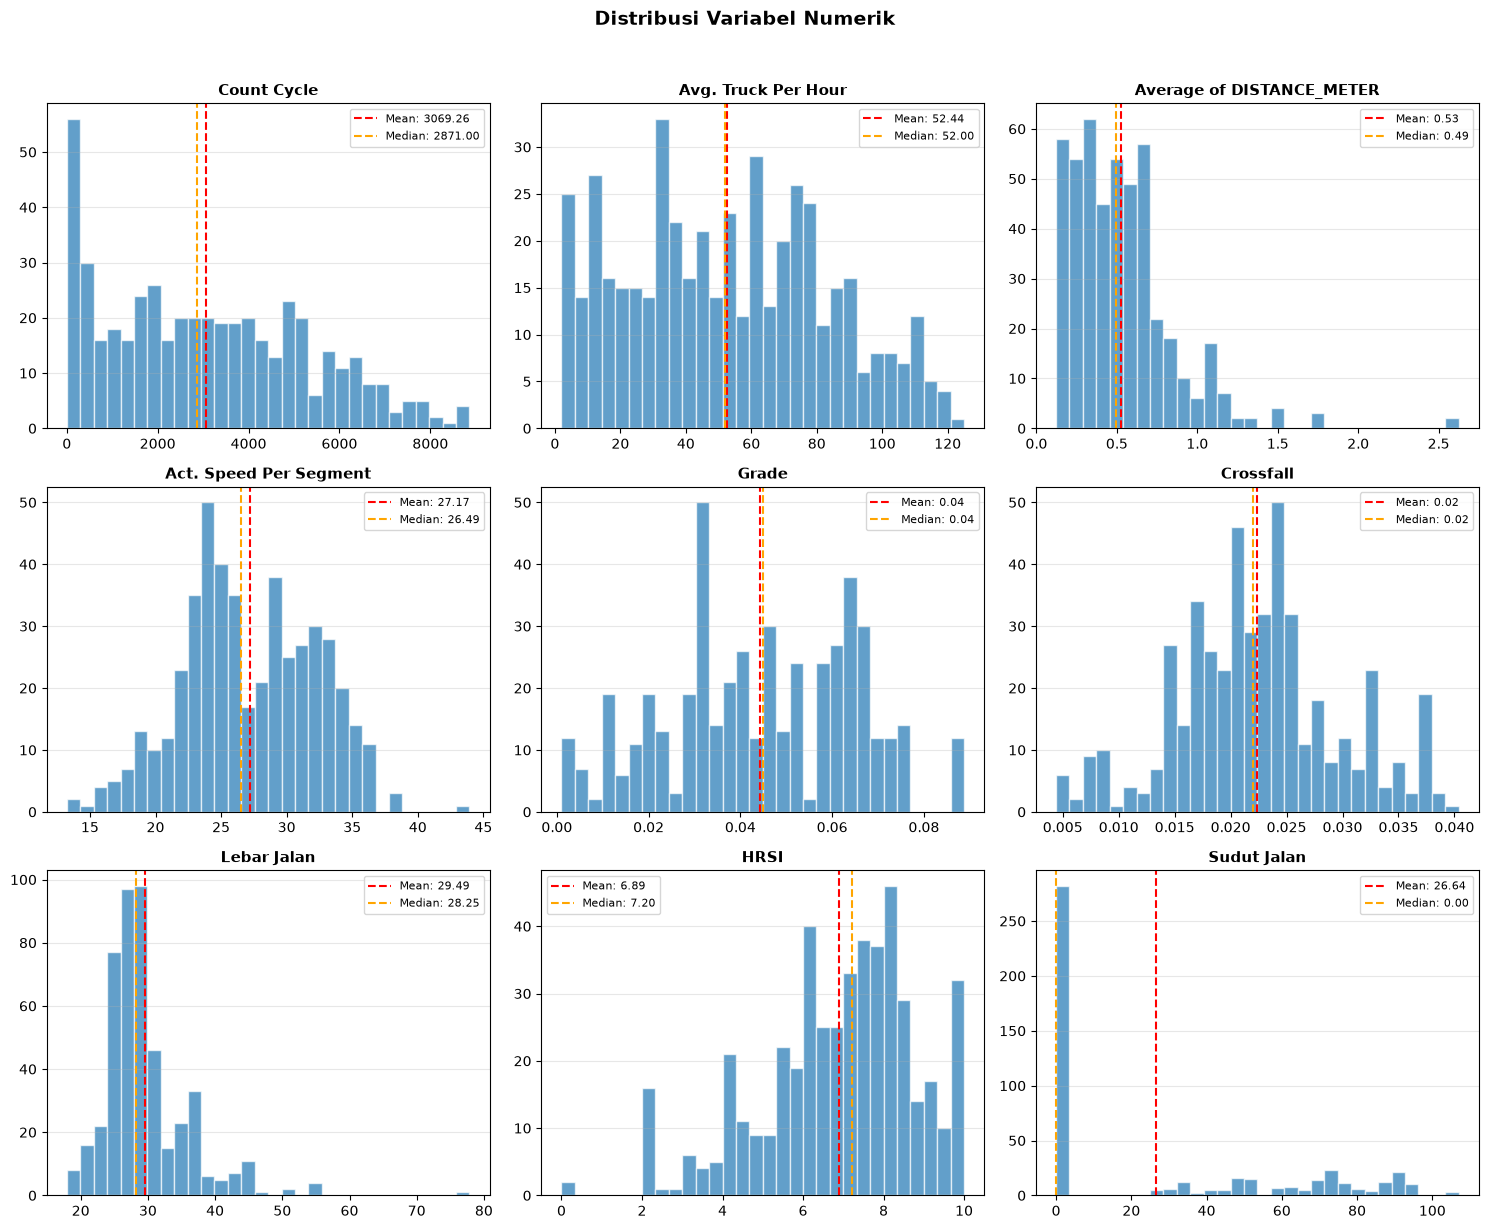

In [4]:
num_cols = ['Count Cycle', 'Avg. Truck Per Hour', 'Average of DISTANCE_METER',
            'Act. Speed Per Segment', 'Grade', 'Crossfall', 'Lebar Jalan', 'HRSI', 'Sudut Jalan']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=30, color='#1f77b4', alpha=0.7, edgecolor='white')
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.2f}')
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {data.median():.2f}')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribusi Variabel Numerik', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 3. EDA - Plan vs Actual Speed

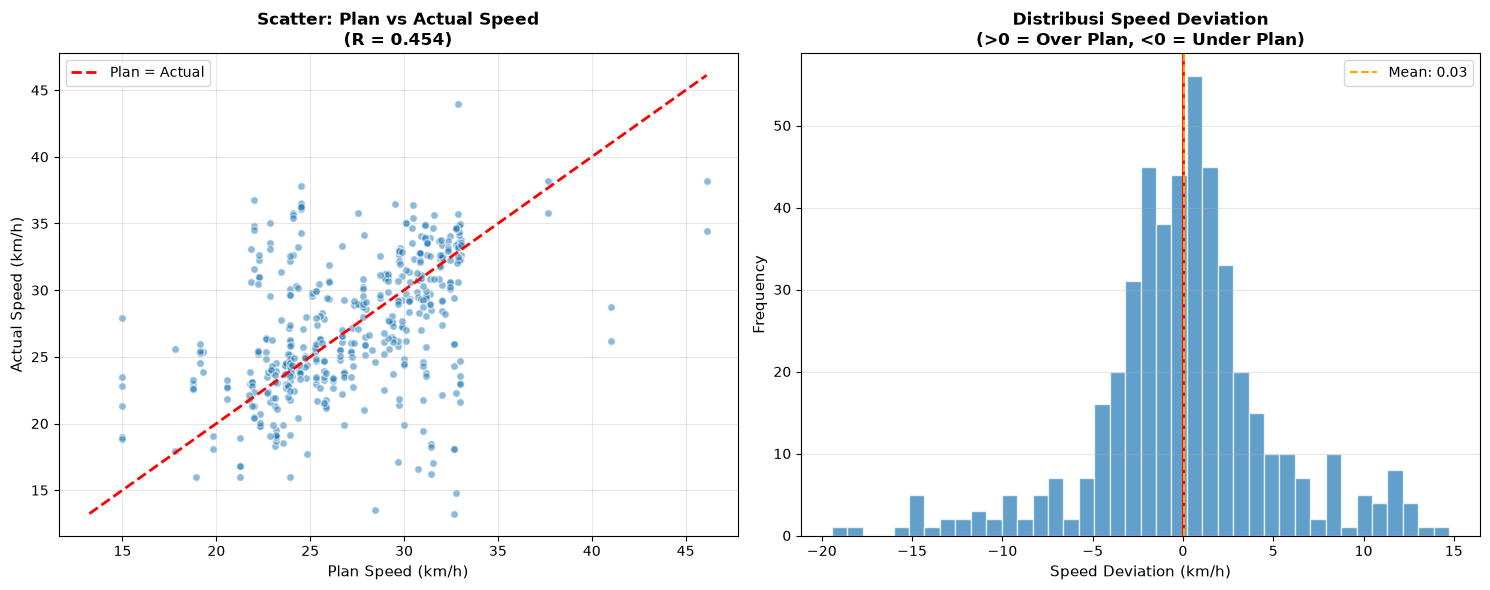

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
ax.scatter(df['Plan Speed Per Segment'], df['Act. Speed Per Segment'], 
           alpha=0.5, s=30, color='#1f77b4', edgecolors='white')
lims = [min(df['Plan Speed Per Segment'].min(), df['Act. Speed Per Segment'].min()),
        max(df['Plan Speed Per Segment'].max(), df['Act. Speed Per Segment'].max())]
ax.plot(lims, lims, '--', color='red', linewidth=2, label='Plan = Actual')
ax.set_xlabel('Plan Speed (km/h)', fontsize=11)
ax.set_ylabel('Actual Speed (km/h)', fontsize=11)
ax.set_title(f'Scatter: Plan vs Actual Speed\n(R = {df["Plan Speed Per Segment"].corr(df["Act. Speed Per Segment"]):.3f})', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
dev = df['Speed_Deviation'].dropna()
ax.hist(dev, bins=40, color='#1f77b4', alpha=0.7, edgecolor='white')
ax.axvline(0, color='red', linestyle='-', linewidth=2)
ax.axvline(dev.mean(), color='orange', linestyle='--', linewidth=1.5, label=f'Mean: {dev.mean():.2f}')
ax.set_xlabel('Speed Deviation (km/h)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Distribusi Speed Deviation\n(>0 = Over Plan, <0 = Under Plan)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4. EDA - Heatmap Korelasi

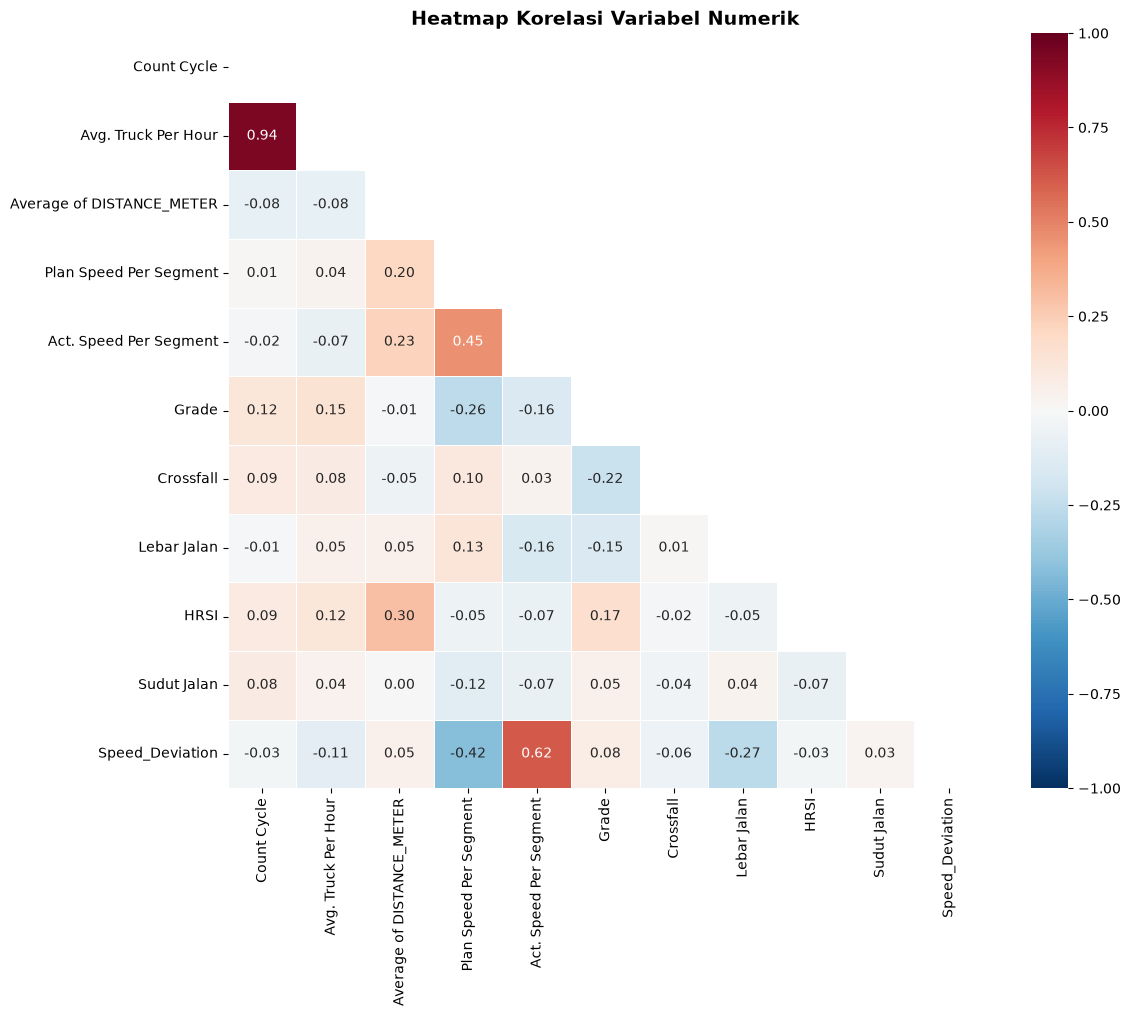

In [6]:
corr_cols = ['Count Cycle', 'Avg. Truck Per Hour', 'Average of DISTANCE_METER',
              'Plan Speed Per Segment', 'Act. Speed Per Segment', 'Grade', 
              'Crossfall', 'Lebar Jalan', 'HRSI', 'Sudut Jalan', 'Speed_Deviation']

fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Heatmap Korelasi Variabel Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. EDA - Tren Mingguan

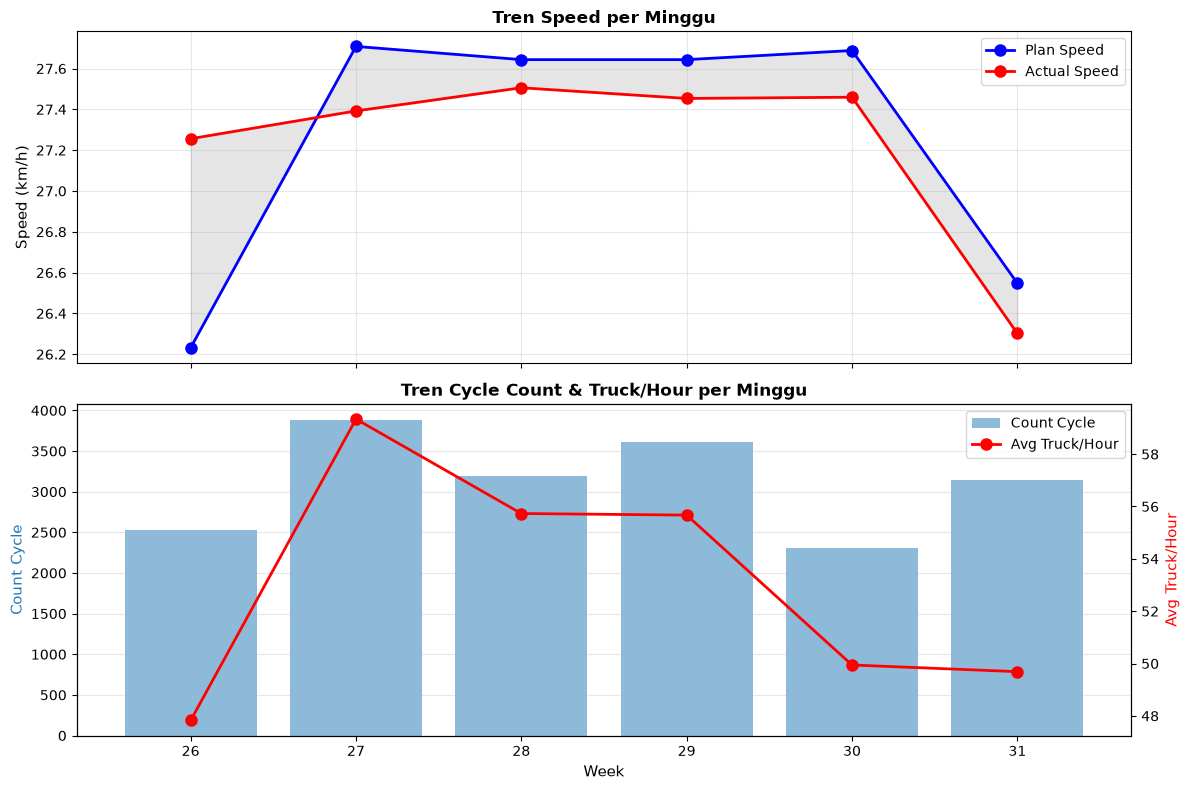

In [7]:
weekly = df.groupby('WEEK').agg({
    'Act. Speed Per Segment': 'mean',
    'Plan Speed Per Segment': 'mean',
    'Count Cycle': 'mean',
    'Avg. Truck Per Hour': 'mean'
}).reset_index().sort_values('WEEK')

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax = axes[0]
ax.plot(weekly['WEEK'], weekly['Plan Speed Per Segment'], 'b-o', label='Plan Speed', linewidth=2, markersize=8)
ax.plot(weekly['WEEK'], weekly['Act. Speed Per Segment'], 'r-o', label='Actual Speed', linewidth=2, markersize=8)
ax.fill_between(weekly['WEEK'], weekly['Plan Speed Per Segment'], weekly['Act. Speed Per Segment'], alpha=0.2, color='gray')
ax.set_ylabel('Speed (km/h)', fontsize=11)
ax.set_title('Tren Speed per Minggu', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

ax = axes[1]
ax2 = ax.twinx()
ax.bar(weekly['WEEK'], weekly['Count Cycle'], color='#1f77b4', alpha=0.5, label='Count Cycle')
ax2.plot(weekly['WEEK'], weekly['Avg. Truck Per Hour'], 'r-o', label='Avg Truck/Hour', linewidth=2, markersize=8)
ax.set_xlabel('Week', fontsize=11)
ax.set_ylabel('Count Cycle', color='#1f77b4', fontsize=11)
ax2.set_ylabel('Avg Truck/Hour', color='red', fontsize=11)
ax.set_title('Tren Cycle Count & Truck/Hour per Minggu', fontsize=12, fontweight='bold')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. EDA - Top/Bottom Road Segments

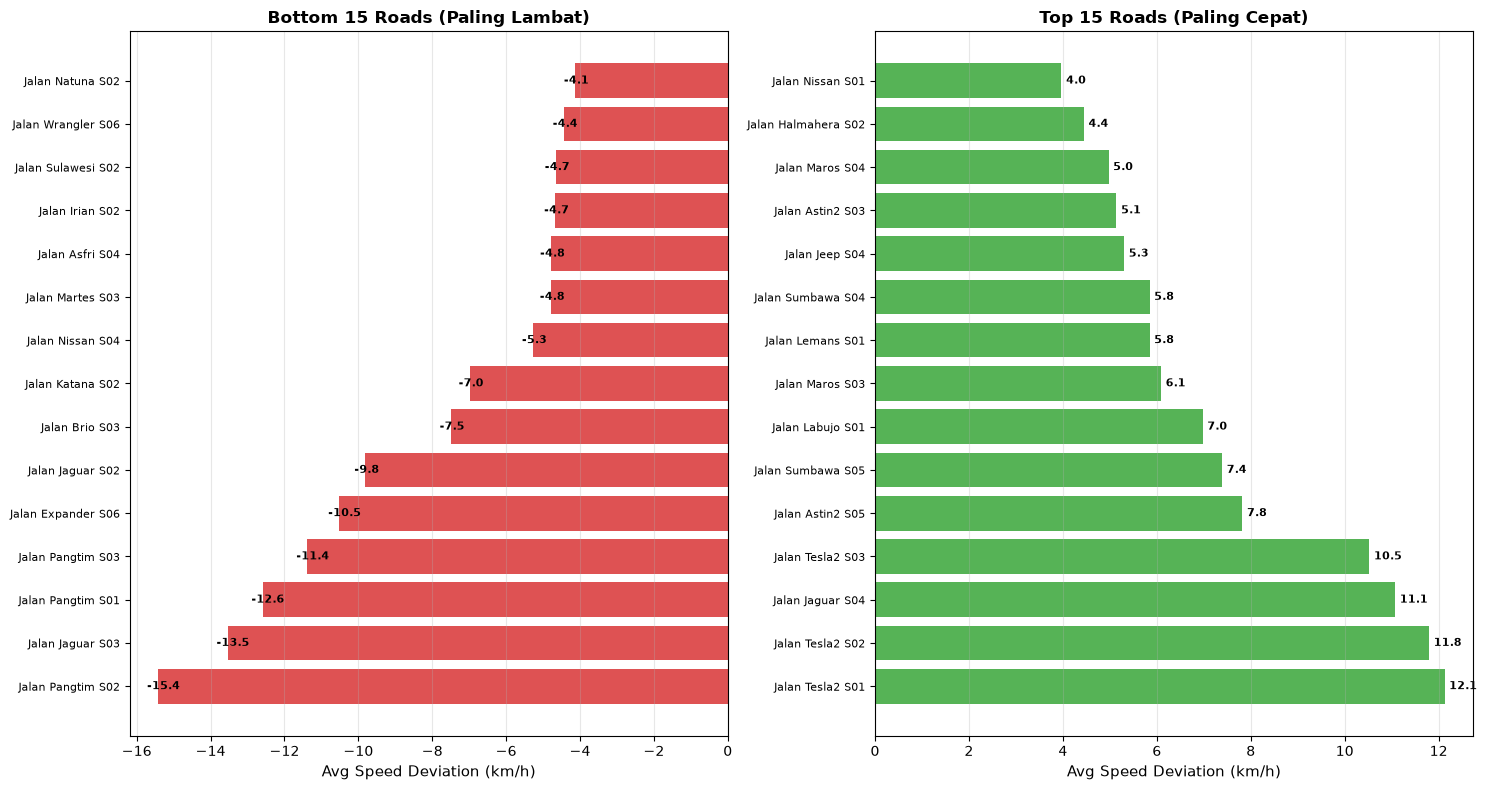

In [8]:
road_perf = df.groupby('Road Segment').agg({
    'Speed_Deviation': 'mean',
    'Count Cycle': 'mean',
    'Act. Speed Per Segment': 'mean'
}).sort_values('Speed_Deviation')

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

ax = axes[0]
bottom = road_perf.head(15)
colors_bottom = ['#d62728' if x < 0 else '#ff7f0e' for x in bottom['Speed_Deviation']]
ax.barh(range(len(bottom)), bottom['Speed_Deviation'], color=colors_bottom, alpha=0.8)
ax.set_yticks(range(len(bottom)))
ax.set_yticklabels(bottom.index, fontsize=8)
for i, val in enumerate(bottom['Speed_Deviation']):
    ax.text(val - 0.3 if val < 0 else val + 0.1, i, f'{val:.1f}', va='center', fontsize=8, fontweight='bold')
ax.set_xlabel('Avg Speed Deviation (km/h)', fontsize=11)
ax.set_title('Bottom 15 Roads (Paling Lambat)', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

ax = axes[1]
top = road_perf.tail(15).sort_values('Speed_Deviation', ascending=False)
colors_top = ['#2ca02c' if x > 0 else '#1f77b4' for x in top['Speed_Deviation']]
ax.barh(range(len(top)), top['Speed_Deviation'], color=colors_top, alpha=0.8)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top.index, fontsize=8)
for i, val in enumerate(top['Speed_Deviation']):
    ax.text(val + 0.1, i, f'{val:.1f}', va='center', fontsize=8, fontweight='bold')
ax.set_xlabel('Avg Speed Deviation (km/h)', fontsize=11)
ax.set_title('Top 15 Roads (Paling Cepat)', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 7. EDA - Grade vs Speed

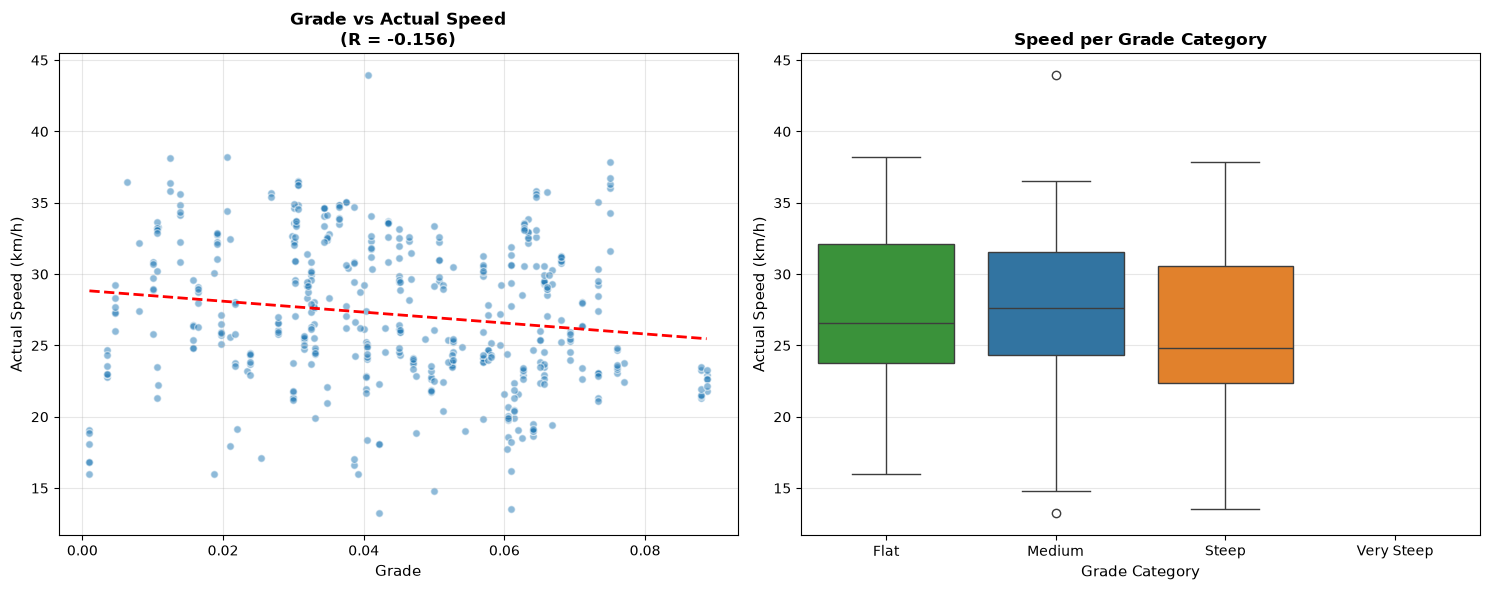

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
ax.scatter(df['Grade'], df['Act. Speed Per Segment'], alpha=0.5, s=30, color='#1f77b4', edgecolors='white')
z = np.polyfit(df['Grade'].dropna(), df['Act. Speed Per Segment'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(df['Grade'].min(), df['Grade'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='red', linewidth=2)
ax.set_xlabel('Grade', fontsize=11)
ax.set_ylabel('Actual Speed (km/h)', fontsize=11)
ax.set_title(f'Grade vs Actual Speed\n(R = {df["Grade"].corr(df["Act. Speed Per Segment"]):.3f})', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

ax = axes[1]
df_plot = df[df['Grade_Category'].notna()]
order = ['Flat', 'Medium', 'Steep', 'Very Steep']
palette = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728']
sns.boxplot(data=df_plot, x='Grade_Category', y='Act. Speed Per Segment', 
            order=order, palette=palette, ax=ax)
ax.set_xlabel('Grade Category', fontsize=11)
ax.set_ylabel('Actual Speed (km/h)', fontsize=11)
ax.set_title('Speed per Grade Category', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 10. Feature Selection
Mencari fitur paling relevan menggunakan RFE dan Mutual Information.

In [12]:
all_features = ['Grade', 'Crossfall', 'Lebar Jalan', 'Min Lebar Jalan', 
                'HRSI', 'Sudut Jalan', 'Average of DISTANCE_METER']
target = 'Act. Speed Per Segment'

X_all = df[all_features].dropna()
y_all = df.loc[X_all.index, target]

# Mutual Information
mi_scores = mutual_info_regression(X_all, y_all, random_state=42)
mi_df = pd.DataFrame({'Feature': all_features, 'MI Score': mi_scores}).sort_values('MI Score', ascending=False)

# RFE dengan Random Forest
rfe = RFE(RandomForestRegressor(n_estimators=50, random_state=42), n_features_to_select=5)
rfe.fit(X_all, y_all)
rfe_df = pd.DataFrame({'Feature': all_features, 'Selected': rfe.support_, 'Ranking': rfe.ranking_})

print('=== Mutual Information Scores ===')
print(mi_df.to_string(index=False))
print('\n=== RFE Ranking ===')
print(rfe_df.sort_values('Ranking').to_string(index=False))

# Pilih fitur terbaik
selected_features = mi_df.head(5)['Feature'].tolist()
print(f'\nSelected Features: {selected_features}')

=== Mutual Information Scores ===
                  Feature  MI Score
                    Grade  0.575816
                Crossfall  0.391378
              Lebar Jalan  0.373206
Average of DISTANCE_METER  0.356744
          Min Lebar Jalan  0.308390
              Sudut Jalan  0.165142
                     HRSI  0.052547

=== RFE Ranking ===
                  Feature  Selected  Ranking
                    Grade      True        1
              Lebar Jalan      True        1
          Min Lebar Jalan      True        1
                     HRSI      True        1
Average of DISTANCE_METER      True        1
                Crossfall     False        2
              Sudut Jalan     False        3

Selected Features: ['Grade', 'Crossfall', 'Lebar Jalan', 'Average of DISTANCE_METER', 'Min Lebar Jalan']


---
## 11. Model Training dengan Hyperparameter Tuning

In [13]:
X = df[selected_features].dropna()
y = df.loc[X.index, target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples')
print(f'Selected Features: {selected_features}')

Train: 377 samples, Test: 95 samples
Selected Features: ['Grade', 'Crossfall', 'Lebar Jalan', 'Average of DISTANCE_METER', 'Min Lebar Jalan']


In [14]:
# Define models dengan hyperparameter grids
param_grids = {
    'Ridge': {'alpha': [0.01, 0.1, 1.0, 10.0]},
    'Lasso': {'alpha': [0.001, 0.01, 0.1, 1.0]},
    'Random Forest': {'n_estimators': [100, 200], 'max_depth': [5, 10, 15], 'min_samples_split': [2, 5]},
    'XGBoost': {'n_estimators': [100, 200], 'max_depth': [3, 6], 'learning_rate': [0.01, 0.1]}
}

base_models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': xgb.XGBRegressor(random_state=42, verbosity=0)
}

results = {}
best_models = {}

for name, model in base_models.items():
    try:
        if name in param_grids:
            if name in ['Ridge', 'Lasso']:
                gs = GridSearchCV(model, param_grids[name], cv=5, scoring='r2', n_jobs=1)
                gs.fit(X_train_scaled, y_train)
            else:
                gs = GridSearchCV(model, param_grids[name], cv=5, scoring='r2', n_jobs=1)
                gs.fit(X_train, y_train)
            best_models[name] = gs.best_estimator_
        else:
            model.fit(X_train_scaled, y_train)
            best_models[name] = model
        
        if name in ['Linear Regression', 'Ridge', 'Lasso']:
            y_pred = best_models[name].predict(X_test_scaled)
            cv_scores = cross_val_score(best_models[name], X_train_scaled, y_train, cv=5, scoring='r2')
        else:
            y_pred = best_models[name].predict(X_test)
            cv_scores = cross_val_score(best_models[name], X_train, y_train, cv=5, scoring='r2')
        
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        results[name] = {
            'R2': r2, 'MAE': mae, 'RMSE': rmse,
            'CV_R2_Mean': cv_scores.mean(), 'CV_R2_Std': cv_scores.std(),
            'y_pred': y_pred, 'best_params': gs.best_params_ if name in param_grids else 'default'
        }
        print(f'{name}: R²={r2:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}, CV_R²={cv_scores.mean():.4f}±{cv_scores.std():.4f}')
    except Exception as e:
        print(f'ERROR {name}: {e}')

Linear Regression: R²=0.0059, MAE=3.9002, RMSE=4.8136, CV_R²=0.0775±0.0822
Ridge: R²=0.0087, MAE=3.9023, RMSE=4.8068, CV_R²=0.0790±0.0810
Lasso: R²=0.0174, MAE=3.8877, RMSE=4.7857, CV_R²=0.0809±0.0788
Random Forest: R²=0.6427, MAE=2.0097, RMSE=2.8858, CV_R²=0.5542±0.1235
XGBoost: R²=0.6444, MAE=1.8837, RMSE=2.8788, CV_R²=0.5442±0.1393


---
## 12. Komparasi Performa Model

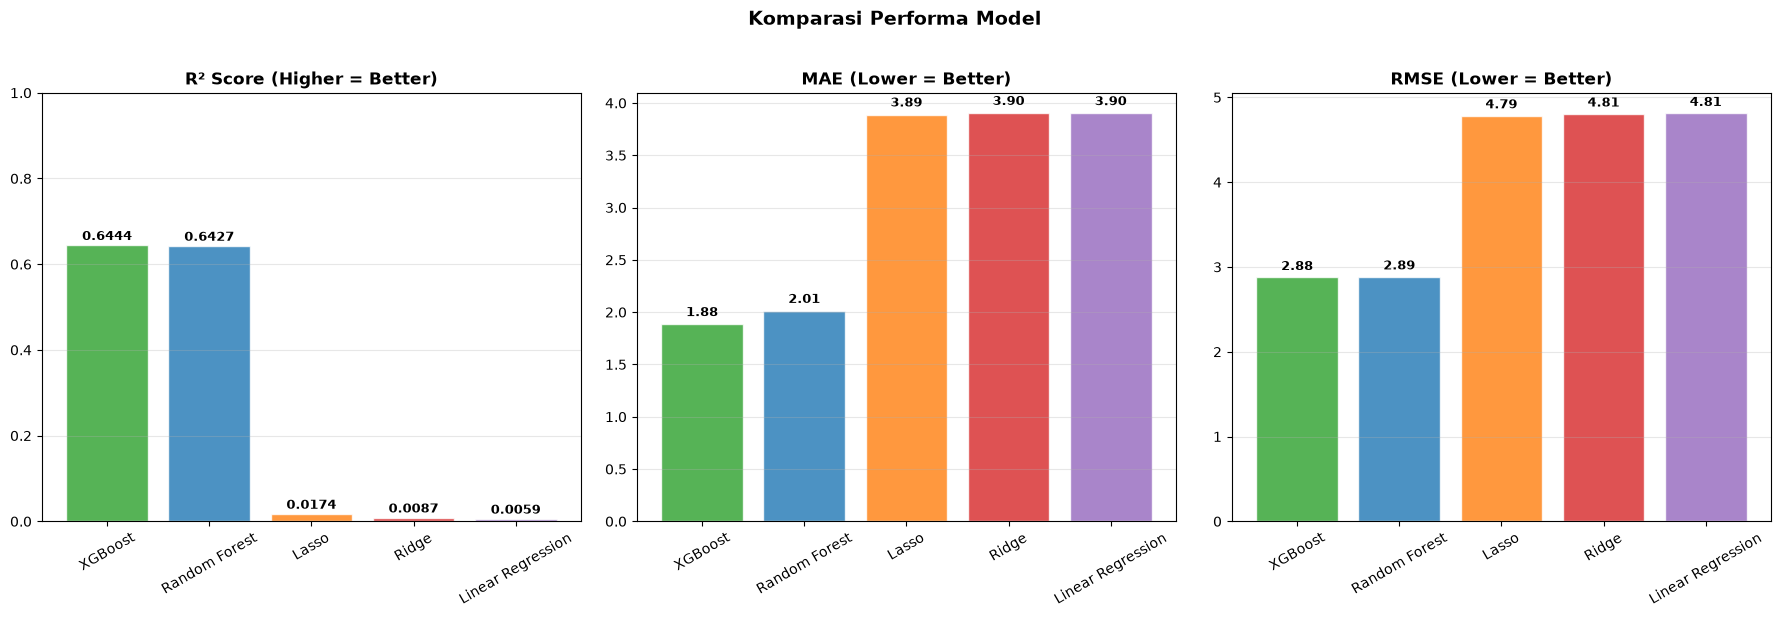


=== Ranking ===
                         R2       MAE      RMSE CV_R2_Mean CV_R2_Std
XGBoost            0.644437  1.883711  2.878777   0.544165  0.139256
Random Forest      0.642702  2.009707   2.88579   0.554168  0.123527
Lasso              0.017365  3.887653  4.785703   0.080931  0.078837
Ridge              0.008689   3.90231  4.806785   0.079028  0.080988
Linear Regression  0.005865    3.9002  4.813625   0.077453  0.082209


In [15]:
res_df = pd.DataFrame(results).T[['R2', 'MAE', 'RMSE', 'CV_R2_Mean', 'CV_R2_Std']]
res_df = res_df.sort_values('R2', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728', '#9467bd']

for i, (metric, title) in enumerate([('R2', 'R² Score (Higher = Better)'), 
                                       ('MAE', 'MAE (Lower = Better)'), 
                                       ('RMSE', 'RMSE (Lower = Better)')]):
    ax = axes[i]
    bars = ax.bar(res_df.index, res_df[metric], color=colors, alpha=0.8, edgecolor='white')
    for bar, val in zip(bars, res_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.005 if metric == 'R2' else 0.05), 
                f'{val:.4f}' if metric == 'R2' else f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)
    if metric == 'R2': ax.set_ylim(0, 1)

plt.suptitle('Komparasi Performa Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n=== Ranking ===')
print(res_df.to_string())

---
## 13. Feature Importance Analysis
Membandingkan feature importance dari semua model.

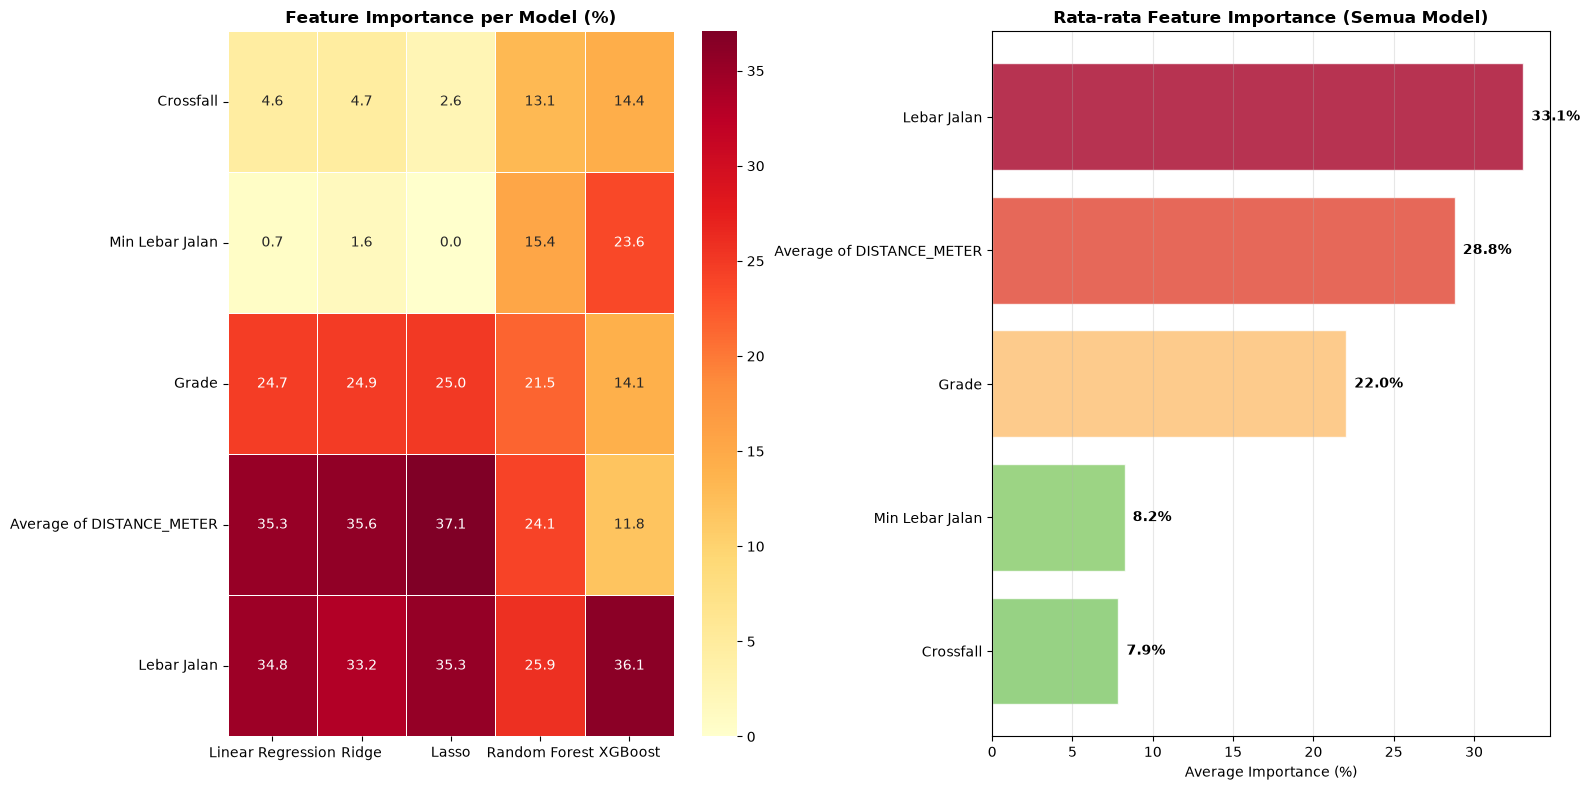

In [16]:
feat_imp = pd.DataFrame(index=selected_features)

for name in ['Linear Regression', 'Ridge', 'Lasso']:
    coefs = np.abs(best_models[name].coef_)
    feat_imp[name] = coefs / coefs.sum() * 100

feat_imp['Random Forest'] = best_models['Random Forest'].feature_importances_ / best_models['Random Forest'].feature_importances_.sum() * 100
feat_imp['XGBoost'] = best_models['XGBoost'].feature_importances_ / best_models['XGBoost'].feature_importances_.sum() * 100
feat_imp['Average'] = feat_imp.mean(axis=1)
feat_imp = feat_imp.sort_values('Average', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

ax = axes[0]
sns.heatmap(feat_imp.drop(columns='Average'), annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Feature Importance per Model (%)', fontweight='bold')
ax.set_ylabel('')

ax = axes[1]
colors_imp = plt.cm.RdYlGn_r(feat_imp['Average'].values / feat_imp['Average'].max())
bars = ax.barh(feat_imp.index, feat_imp['Average'], color=colors_imp, alpha=0.8, edgecolor='white')
for bar, val in zip(bars, feat_imp['Average']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Average Importance (%)')
ax.set_title('Rata-rata Feature Importance (Semua Model)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 14. Model Terbaik - Detailed Analysis

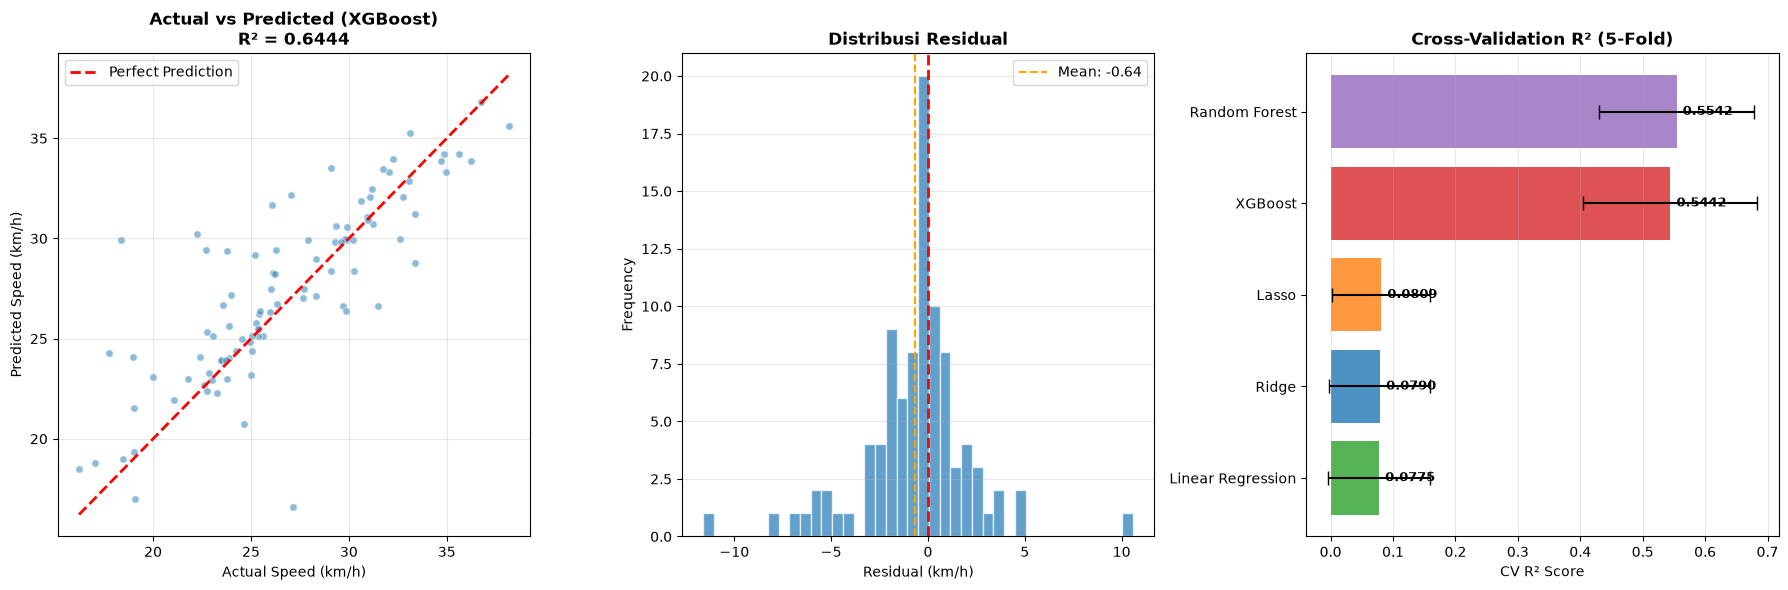

In [17]:
best_model_name = res_df.index[0]
best_model = best_models[best_model_name]

if best_model_name in ['Linear Regression', 'Ridge', 'Lasso']:
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Actual vs Predicted
ax = axes[0]
ax.scatter(y_test, y_pred_best, alpha=0.5, s=30, color='#1f77b4', edgecolors='white')
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
ax.plot(lims, lims, '--', color='red', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Speed (km/h)')
ax.set_ylabel('Predicted Speed (km/h)')
ax.set_title(f'Actual vs Predicted ({best_model_name})\nR² = {results[best_model_name]["R2"]:.4f}', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Residual
ax = axes[1]
residuals = y_test - y_pred_best
ax.hist(residuals, bins=40, color='#1f77b4', alpha=0.7, edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.axvline(residuals.mean(), color='orange', linestyle='--', linewidth=1.5, label=f'Mean: {residuals.mean():.2f}')
ax.set_xlabel('Residual (km/h)')
ax.set_ylabel('Frequency')
ax.set_title('Distribusi Residual', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# CV scores
ax = axes[2]
cv_data = {name: [results[name]['CV_R2_Mean'], results[name]['CV_R2_Std']] for name in results.keys()}
cv_df = pd.DataFrame(cv_data, index=['Mean', 'Std']).T.sort_values('Mean', ascending=True)
bars = ax.barh(cv_df.index, cv_df['Mean'], xerr=cv_df['Std'], color=colors[:len(cv_df)], alpha=0.8, capsize=5)
for bar, val in zip(bars, cv_df['Mean']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('CV R² Score')
ax.set_title('Cross-Validation R² (5-Fold)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 15. SHAP Analysis
SHAP (SHapley Additive exPlanations) menjelaskan kontribusi setiap fitur terhadap prediksi model.

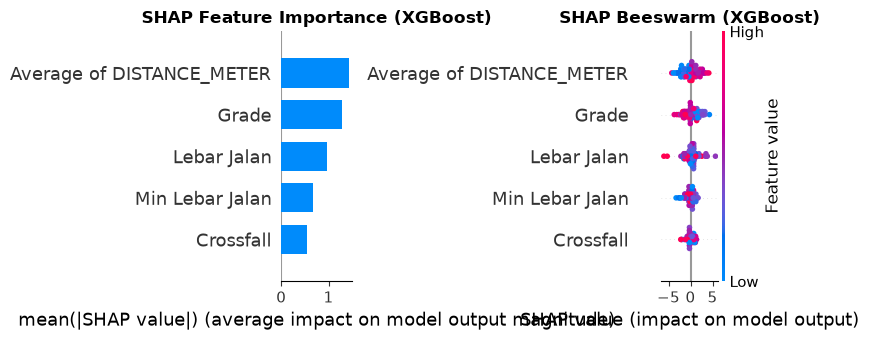


=== SHAP Interpretation ===
SHAP menunjukkan seberapa besar pengaruh setiap fitur terhadap prediksi.
Positif = menambah nilai prediksi, Negatif = mengurangi nilai prediksi.
Fitur paling berpengaruh: Grade


In [18]:
if best_model_name in ['Random Forest', 'XGBoost']:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
    shap_X = X_test
else:
    explainer = shap.LinearExplainer(best_model, X_train_scaled)
    shap_values = explainer.shap_values(X_test_scaled)
    shap_X = pd.DataFrame(X_test_scaled, columns=selected_features)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

plt.sca(axes[0])
shap.summary_plot(shap_values, shap_X, feature_names=selected_features, show=False, plot_type='bar')
axes[0].set_title(f'SHAP Feature Importance ({best_model_name})', fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(shap_values, shap_X, feature_names=selected_features, show=False)
axes[1].set_title(f'SHAP Beeswarm ({best_model_name})', fontweight='bold')

plt.tight_layout()
plt.show()

print('\n=== SHAP Interpretation ===')
print('SHAP menunjukkan seberapa besar pengaruh setiap fitur terhadap prediksi.')
print('Positif = menambah nilai prediksi, Negatif = mengurangi nilai prediksi.')
print(f'Fitur paling berpengaruh: {selected_features[0]}')

---
## 16. Save Model

In [19]:
MODEL_PATH = 'best_road_speed_model.pkl'
SCALER_PATH = 'road_speed_scaler.pkl'
FEATURES_PATH = 'road_speed_features.pkl'

joblib.dump(best_model, MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)
joblib.dump(selected_features, FEATURES_PATH)

print(f'Model saved: {MODEL_PATH}')
print(f'Scaler saved: {SCALER_PATH}')
print(f'Features saved: {FEATURES_PATH}')

Model saved: best_road_speed_model.pkl
Scaler saved: road_speed_scaler.pkl
Features saved: road_speed_features.pkl


---
## 17. Predict Function
Fungsi untuk memprediksi kecepatan aktual berdasarkan kondisi jalan baru.

In [20]:
def predict_speed(grade=0, crossfall=0, lebar_jalan=0, min_lebar_jalan=0, hrsi=0, sudut_jalan=0, distance=0):
    """Prediksi Actual Speed berdasarkan kondisi jalan."""
    params = {
        'Grade': grade, 'Crossfall': crossfall, 'Lebar Jalan': lebar_jalan,
        'Min Lebar Jalan': min_lebar_jalan, 'HRSI': hrsi, 
        'Sudut Jalan': sudut_jalan, 'Average of DISTANCE_METER': distance
    }
    input_data = pd.DataFrame([[params.get(f, 0) for f in selected_features]], columns=selected_features)
    
    if best_model_name in ['Linear Regression', 'Ridge', 'Lasso']:
        prediction = best_model.predict(scaler.transform(input_data))[0]
    else:
        prediction = best_model.predict(input_data)[0]
    return prediction

print('=== Contoh Prediksi ===')
pred = predict_speed(grade=0.05, crossfall=0.02, lebar_jalan=25, hrsi=7.0, sudut_jalan=30)
print(f'Prediksi Kecepatan: {pred:.2f} km/h')

=== Contoh Prediksi ===
Prediksi Kecepatan: 27.17 km/h


---
## 18. Kesimpulan

In [ ]:
print('=' * 60)
print('KESIMPULAN ANALISIS')
print('=' * 60)
print(f'\nBest Model: {best_model_name}')
print(f'  R² Score: {results[best_model_name]["R2"]:.4f}')
print(f'  MAE: {results[best_model_name]["MAE"]:.4f} km/h')
print(f'  CV R²: {results[best_model_name]["CV_R2_Mean"]:.4f} ± {results[best_model_name]["CV_R2_Std"]:.4f}')
print(f'\nBest Parameters: {results[best_model_name]["best_params"]}')
print(f'\nTop 3 Fitur Paling Penting:')
top3 = feat_imp['Average'].tail(3)
for i in range(3, 0, -1):
    print(f'  {4-i}. {top3.index[i-1]}: {top3.values[i-1]:.1f}%')
print(f'\nInterpretasi:')
print(f'  - Model menjelaskan {results[best_model_name]["R2"]*100:.1f}% variansi Actual Speed')
print(f'  - Error rata-rata: {results[best_model_name]["MAE"]:.2f} km/h')
print(f'  - Fitur paling berpengaruh: {top3.index[-1]}')
print(f'\nModel tersimpan di: {MODEL_PATH}')

KESIMPULAN ANALISIS

Best Model: XGBoost
  R² Score: 0.6444
  MAE: 1.8837 km/h
  CV R²: 0.5442 ± 0.1393

Best Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}

Top 3 Fitur Paling Penting:
  1. Lebar Jalan: 33.1%
  2. Average of DISTANCE_METER: 28.8%
  3. Grade: 22.0%

Interpretasi:
  - Model menjelaskan 64.4% variansi Actual Speed
  - Error rata-rata: 1.88 km/h
  - Fitur paling berpengaruh: Lebar Jalan

Model tersimpan di: best_road_speed_model.pkl


: 